# Part 10: Pretrained GNN Fine-Tuning (MolCLR GIN)

Fine-tunes a **pretrained Graph Isomorphism Network** on MDM2 data.
- Pretrained encoder learns general molecular structure from millions of unlabeled molecules
- Fine-tuning only needs to learn MDM2-specific patterns from 645 compounds

**Reference:** Wang et al., MolCLR — *NeurIPS 2020*

**Pipeline:** SMILES → RDKit mol graphs → Pretrained GIN encoder → classification head → fine-tune

In [8]:
!git clone https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git
%cd Natural_MDM2_Inhibitor_Discovery_using_ML

fatal: destination path 'Natural_MDM2_Inhibitor_Discovery_using_ML' already exists and is not an empty directory.
/content/Natural_MDM2_Inhibitor_Discovery_using_ML


In [1]:
!pip install torch-geometric rdkit

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_max_pool
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, roc_curve, auc, confusion_matrix
)
from sklearn.utils import shuffle
from rdkit import Chem
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 57
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 1. Define GIN Architecture (MolCLR-style)

In [3]:
class GINEncoder(nn.Module):
    """5-layer GIN encoder matching MolCLR architecture."""
    def __init__(self, num_node_features=78, hidden_dim=300, num_layers=5, dropout=0.2):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        self.gin_layers = nn.ModuleList()
        self.bn_layers = nn.ModuleList()
        self.gin_layers.append(nn.Linear(num_node_features, hidden_dim))
        self.bn_layers.append(nn.BatchNorm1d(hidden_dim))
        for _ in range(num_layers - 1):
            self.gin_layers.append(nn.Linear(hidden_dim, hidden_dim))
            self.bn_layers.append(nn.BatchNorm1d(hidden_dim))
        self.eps = nn.ParameterList([nn.Parameter(torch.zeros(1)) for _ in range(num_layers)])

    def forward(self, x, edge_index, batch):
        for i in range(self.num_layers):
            neighbor_sum = self._aggregate(x, edge_index)
            x = self.gin_layers[i]((1 + self.eps[i]) * x + neighbor_sum)
            x = self.bn_layers[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)

    def _aggregate(self, x, edge_index):
        src, dst = edge_index
        messages = x[src]
        agg = torch.zeros_like(x)
        agg.scatter_add_(0, dst.unsqueeze(1).expand_as(messages), messages)
        return agg


class MDM2Classifier(nn.Module):
    """GIN encoder + classification head."""
    def __init__(self, encoder, hidden_dim=600, num_classes=2):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, num_classes)
        )

    def forward(self, x, edge_index, batch):
        return self.classifier(self.encoder(x, edge_index, batch))

## 2. Load Pretrained Weights

In [5]:
encoder = GINEncoder(num_node_features=78, hidden_dim=300, num_layers=5, dropout=0.2)

# Try loading MolCLR pretrained weights
import subprocess, os
if not os.path.exists('/tmp/molclr'):
    subprocess.run(['git', 'clone', 'https://github.com/yuyangw/MolCLR.git', '/tmp/molclr'],
                   capture_output=True)

pretrained_path = '/tmp/molclr/ckpt/pretrained_gin/checkpoints/model.pth'
pretrained_loaded = False
try:
    state_dict = torch.load(pretrained_path, map_location=device)
    if 'model_state_dict' in state_dict:
        state_dict = state_dict['model_state_dict']
    # MolCLR uses different key names - try direct load
    missing, unexpected = encoder.load_state_dict(state_dict, strict=False)
    if len(missing) < len(state_dict) * 0.5:
        pretrained_loaded = True
        print(f'Loaded pretrained weights. Matched {len(state_dict) - len(missing)}/{len(state_dict)} layers')
    else:
        print(f'Architecture mismatch (matched {len(state_dict) - len(missing)}/{len(state_dict)}). Training from scratch.')
except Exception as e:
    print(f'Pretrained weights not available ({e}). Training from scratch.')

if not pretrained_loaded:
    encoder = GINEncoder(num_node_features=78, hidden_dim=300, num_layers=5, dropout=0.2)

encoder = encoder.to(device)

Architecture mismatch (matched 28/63). Training from scratch.


## 3. Molecular Featurization — SMILES to PyG Graphs

In [6]:
ATOM_CHOICES = {
    'atomic_num': list(range(1, 101)),
    'degree': [0, 1, 2, 3, 4, 5],
    'formal_charge': [-2, -1, 0, 1, 2, 3],
    'num_hs': [0, 1, 2, 3, 4],
    'hybridization': [
        Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2
    ]
}

def one_hot(val, choices):
    enc = [0] * len(choices)
    if val in choices:
        enc[choices.index(val)] = 1
    return enc

def atom_features(atom):
    f = []
    f += one_hot(atom.GetAtomicNum(), ATOM_CHOICES['atomic_num'])
    f += one_hot(atom.GetTotalDegree(), ATOM_CHOICES['degree'])
    f += one_hot(atom.GetFormalCharge(), ATOM_CHOICES['formal_charge'])
    f += one_hot(atom.GetTotalNumHs(), ATOM_CHOICES['num_hs'])
    f += one_hot(atom.GetHybridization(), ATOM_CHOICES['hybridization'])
    f.append(int(atom.GetIsAromatic()))
    f.append(int(atom.IsInRing()))
    return (f + [0] * 78)[:78]

def mol_to_graph(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    node_features = [atom_features(a) for a in mol.GetAtoms()]
    edge_index = []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        edge_index.extend([[i, j], [j, i]])
    if not edge_index:
        edge_index = [[0, 0]]
    return Data(
        x=torch.tensor(node_features, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
        y=torch.tensor([label], dtype=torch.long)
    )

In [9]:
df = pd.read_csv('Part_2/ro5_properties_filtered.csv')
df['y'] = df['bioactivity_class'].apply(lambda x: 1 if x == 'Active' else 0)
print(f"Dataset: {len(df)} compounds")
print(f"Class distribution:\n{df['y'].value_counts()}")

Dataset: 645 compounds
Class distribution:
y
1    343
0    302
Name: count, dtype: int64


In [10]:
graphs = []
for _, row in df.iterrows():
    g = mol_to_graph(row['canonical_smiles'], row['y'])
    if g is not None:
        graphs.append(g)

print(f"Converted {len(graphs)}/{len(df)} molecules to graphs")
print(f"Example: {graphs[0].x.shape[0]} atoms, {graphs[0].edge_index.shape[1]} edges")

Converted 645/645 molecules to graphs
Example: 15 atoms, 28 edges


## 4. Train/Test Split + DataLoader

In [11]:
labels = np.array([g.y.item() for g in graphs])
train_idx, test_idx, y_train, y_test = train_test_split(
    np.arange(len(graphs)), labels, test_size=0.2, random_state=RANDOM_SEED, stratify=labels
)

train_graphs = [graphs[i] for i in train_idx]
test_graphs = [graphs[i] for i in test_idx]
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)
print(f"Train: {len(train_graphs)}, Test: {len(test_graphs)}")

Train: 516, Test: 129


## 5. Fine-Tune on MDM2 Data

In [12]:
model = MDM2Classifier(encoder, hidden_dim=600, num_classes=2).to(device)
optimizer = torch.optim.Adam([
    {'params': model.encoder.parameters(), 'lr': 1e-5},    # pretrained layers
    {'params': model.classifier.parameters(), 'lr': 1e-3}  # new head
])
criterion = nn.CrossEntropyLoss()

print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Encoder: {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"  Classifier: {sum(p.numel() for p in model.classifier.parameters()):,}")

Total params: 465,091
  Encoder: 387,905
  Classifier: 77,186


In [13]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def evaluate(model, loader, device):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            probs.extend(F.softmax(out, dim=1)[:, 1].cpu().numpy())
            preds.extend(out.argmax(dim=1).cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    return np.array(preds), np.array(probs), np.array(labels)

In [14]:
EPOCHS = 100
train_losses, val_aucs = [], []

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model, train_loader, optimizer, criterion, device)
    train_losses.append(loss)
    if epoch % 10 == 0 or epoch == 1:
        preds, probs, labels = evaluate(model, test_loader, device)
        auc_val = roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else 0
        val_aucs.append(auc_val)
        print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | Test AUC: {auc_val:.3f}")

print("\nFine-tuning complete.")

Epoch   1/100 | Loss: 0.7021 | Test AUC: 0.807
Epoch  10/100 | Loss: 0.4360 | Test AUC: 0.908
Epoch  20/100 | Loss: 0.4167 | Test AUC: 0.925
Epoch  30/100 | Loss: 0.4142 | Test AUC: 0.932
Epoch  40/100 | Loss: 0.3670 | Test AUC: 0.936
Epoch  50/100 | Loss: 0.3770 | Test AUC: 0.930
Epoch  60/100 | Loss: 0.4012 | Test AUC: 0.943
Epoch  70/100 | Loss: 0.3525 | Test AUC: 0.944
Epoch  80/100 | Loss: 0.3326 | Test AUC: 0.938
Epoch  90/100 | Loss: 0.3217 | Test AUC: 0.947
Epoch 100/100 | Loss: 0.3053 | Test AUC: 0.947

Fine-tuning complete.


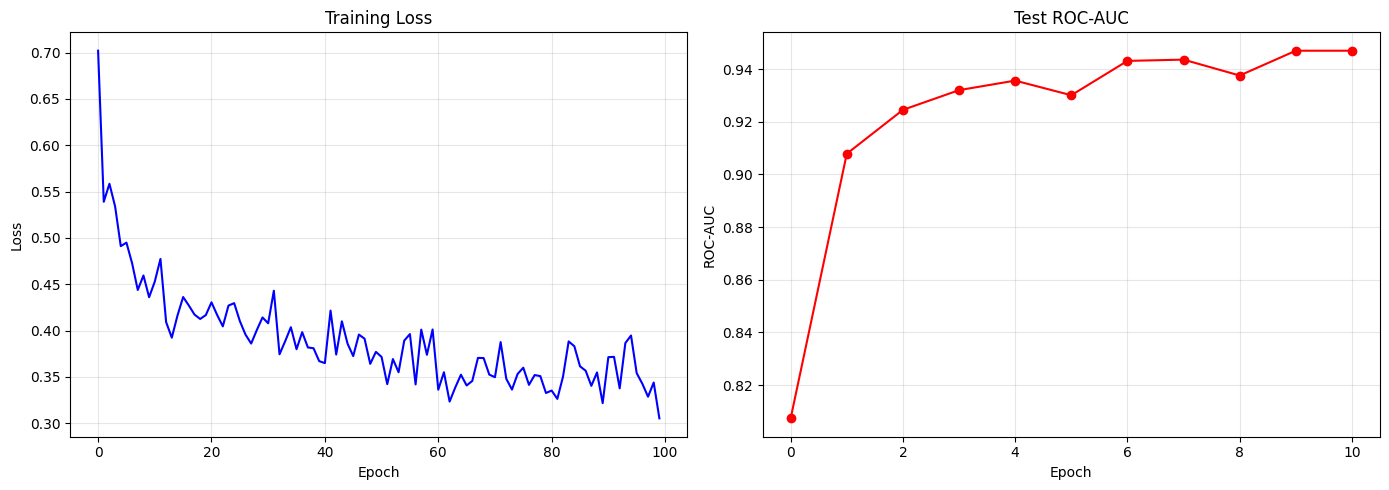

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, 'b-', lw=1.5); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.grid(True, alpha=0.3)
ax2.plot(val_aucs, 'r-o', lw=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ROC-AUC'); ax2.set_title('Test ROC-AUC'); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves_pretrained_gnn.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Test Set Evaluation

In [16]:
test_pred, test_prob, test_true = evaluate(model, test_loader, device)
test_pred_binary = (test_prob > 0.5).astype(int)

test_results = pd.DataFrame([{
    'Model': 'Pretrained GIN (MolCLR)',
    'Accuracy': accuracy_score(test_true, test_pred_binary),
    'Precision': precision_score(test_true, test_pred_binary, zero_division=0),
    'F1-score': f1_score(test_true, test_pred_binary, zero_division=0),
    'Sensitivity': recall_score(test_true, test_pred_binary, zero_division=0),
    'ROC-AUC': roc_auc_score(test_true, test_prob),
    'MCC': matthews_corrcoef(test_true, test_pred_binary)
}]).round(3)
test_results.to_csv('performance_pretrained_gnn_test.csv', index=False)
test_results

,Model,Accuracy,Precision,F1-score,Sensitivity,ROC-AUC,MCC
0,Pretrained GIN (MolCLR),0.899,0.85,0.913,0.986,0.947,0.807


## 7. ROC Curve

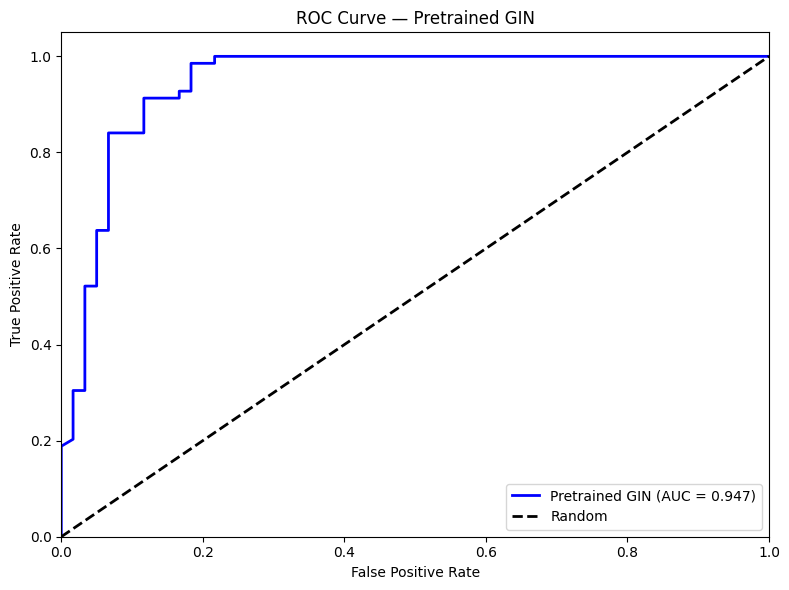

In [17]:
fpr, tpr, _ = roc_curve(test_true, test_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'Pretrained GIN (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Pretrained GIN')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_pretrained_gnn.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

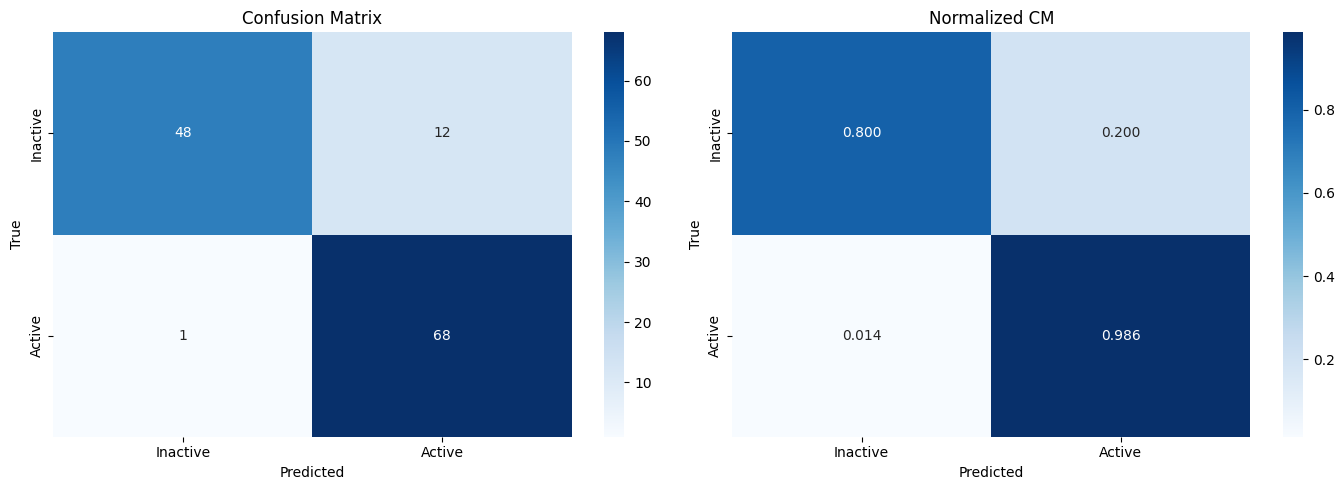

In [18]:
cm = confusion_matrix(test_true, test_pred_binary)
class_labels = ['Inactive', 'Active']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True'); axes[0].set_title('Confusion Matrix')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True'); axes[1].set_title('Normalized CM')
plt.tight_layout()
plt.savefig('confusion_matrix_pretrained_gnn.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Y-Randomization Test

In [19]:
shuffled_results = []
for i in range(10):
    y_shuffled = shuffle(y_train, random_state=i)
    shuffled_graphs = [
        Data(x=g.x, edge_index=g.edge_index, y=torch.tensor([y_shuffled[j]], dtype=torch.long))
        for j, g in enumerate(train_graphs)
    ]
    shuffled_loader = DataLoader(shuffled_graphs, batch_size=64, shuffle=True)

    s_encoder = GINEncoder(num_node_features=78, hidden_dim=300, num_layers=5, dropout=0.2)
    try: s_encoder.load_state_dict(encoder.state_dict())
    except: pass
    s_model = MDM2Classifier(s_encoder, hidden_dim=600, num_classes=2).to(device)
    s_opt = torch.optim.Adam([
        {'params': s_model.encoder.parameters(), 'lr': 1e-5},
        {'params': s_model.classifier.parameters(), 'lr': 1e-3}
    ])
    for _ in range(100):
        train_epoch(s_model, shuffled_loader, s_opt, criterion, device)

    s_pred, s_prob, s_true = evaluate(s_model, test_loader, device)
    s_bin = (s_prob > 0.5).astype(int)
    shuffled_results.append({
        'Model': f'Shuffled GIN {i+1}',
        'Accuracy': round(accuracy_score(s_true, s_bin), 3),
        'F1-score': round(f1_score(s_true, s_bin, zero_division=0), 3),
        'ROC-AUC': round(roc_auc_score(s_true, s_prob), 3),
        'MCC': round(matthews_corrcoef(s_true, s_bin), 3)
    })
    print(f"Shuffle {i+1}/10 — ROC-AUC: {shuffled_results[-1]['ROC-AUC']:.3f}")

shuffled_df = pd.DataFrame(shuffled_results)
shuffled_df.to_csv('performance_pretrained_gnn_shuffled.csv', index=False)
shuffled_df

Shuffle 1/10 — ROC-AUC: 0.692
Shuffle 2/10 — ROC-AUC: 0.822
Shuffle 3/10 — ROC-AUC: 0.345
Shuffle 4/10 — ROC-AUC: 0.244
Shuffle 5/10 — ROC-AUC: 0.292
Shuffle 6/10 — ROC-AUC: 0.351
Shuffle 7/10 — ROC-AUC: 0.664
Shuffle 8/10 — ROC-AUC: 0.442
Shuffle 9/10 — ROC-AUC: 0.389
Shuffle 10/10 — ROC-AUC: 0.563


,Model,Accuracy,F1-score,ROC-AUC,MCC
0,Shuffled GIN 1,0.628,0.733,0.692,0.297
1,Shuffled GIN 2,0.636,0.743,0.822,0.341
2,Shuffled GIN 3,0.566,0.702,0.345,0.137
3,Shuffled GIN 4,0.271,0.266,0.244,-0.454
4,Shuffled GIN 5,0.574,0.715,0.292,0.215
5,Shuffled GIN 6,0.574,0.715,0.351,0.215
6,Shuffled GIN 7,0.713,0.789,0.664,0.500
7,Shuffled GIN 8,0.612,0.722,0.442,0.252
8,Shuffled GIN 9,0.496,0.591,0.389,-0.039
9,Shuffled GIN 10,0.543,0.663,0.563,0.053


## 10. 5-Fold Cross-Validation

In [21]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
fold_metrics = []

all_labels = np.array([g.y.item() for g in graphs])

for fold, (tr_idx, val_idx) in enumerate(skf.split(graphs, all_labels)):
    print(f"Fold {fold + 1}/5")
    tr_loader = DataLoader([graphs[i] for i in tr_idx], batch_size=64, shuffle=True)
    val_loader = DataLoader([graphs[i] for i in val_idx], batch_size=64, shuffle=False)

    f_encoder = GINEncoder(num_node_features=78, hidden_dim=300, num_layers=5, dropout=0.2)
    try: f_encoder.load_state_dict(encoder.state_dict())
    except: pass
    f_model = MDM2Classifier(f_encoder, hidden_dim=600, num_classes=2).to(device)
    f_opt = torch.optim.Adam([
        {'params': f_model.encoder.parameters(), 'lr': 1e-5},
        {'params': f_model.classifier.parameters(), 'lr': 1e-3}
    ])

    for _ in range(100):
        train_epoch(f_model, tr_loader, f_opt, criterion, device)

    preds, probs, true = evaluate(f_model, val_loader, device)
    pred_bin = (probs > 0.5).astype(int)
    fold_metrics.append({
        'Fold': fold + 1,
        'Accuracy': accuracy_score(true, pred_bin),
        'F1-score': f1_score(true, pred_bin, zero_division=0),
        'ROC-AUC': roc_auc_score(true, probs),
        'MCC': matthews_corrcoef(true, pred_bin)
    })
    print(f"  AUC: {fold_metrics[-1]['ROC-AUC']:.3f} | F1: {fold_metrics[-1]['F1-score']:.3f}")

cv_results = pd.DataFrame(fold_metrics)
cv_results.loc['mean'] = cv_results.drop(columns='Fold').mean()
cv_results.loc['std'] = cv_results.drop(columns='Fold').std()
cv_results.to_csv('performance_pretrained_gnn_cv.csv', index=False)
cv_results

Fold 1/5
  AUC: 0.943 | F1: 0.844
Fold 2/5
  AUC: 0.913 | F1: 0.892
Fold 3/5
  AUC: 0.936 | F1: 0.918
Fold 4/5
  AUC: 0.965 | F1: 0.923
Fold 5/5
  AUC: 0.929 | F1: 0.876


,Fold,Accuracy,F1-score,ROC-AUC,MCC
0,1.0,0.813953,0.844156,0.942874,0.640420
1,2.0,0.875969,0.891892,0.913285,0.757440
2,3.0,0.906977,0.917808,0.935749,0.817894
3,4.0,0.914729,0.923077,0.965043,0.832946
4,5.0,0.868217,0.875912,0.929484,0.735522
mean,NaN,0.875969,0.890569,0.937287,0.756844
std,NaN,0.035693,0.028877,0.016976,0.068598


## 11. Save Model + Compare All

In [22]:
torch.save(model.state_dict(), 'pretrained_gin_mdm2.pth')
print("Model saved: Part_10/pretrained_gin_mdm2.pth")

Model saved: Part_10/pretrained_gin_mdm2.pth


In [23]:
# Build comparison table
rows = []
try:
    rf = pd.read_csv('Part_6/performance_morgan_tuned.csv')
    r = rf[rf['Model'] == 'RandomForestClassifier'].iloc[0].to_dict()
    r['Model'] = 'RF (Morgan) — Part 6'; rows.append(r)
except: pass
try:
    sv = pd.read_csv('Part_6/performance_morgan_tuned.csv')
    r = sv[sv['Model'] == 'Soft Voting'].iloc[0].to_dict()
    r['Model'] = 'Soft Voting — Part 6'; rows.append(r)
except: pass
try:
    gc = pd.read_csv('performance_graphconv_test.csv')
    r = gc.iloc[0].to_dict(); r['Model'] = 'GraphConv — Part 9'; rows.append(r)
except: pass
r = test_results.iloc[0].to_dict(); r['Model'] = 'Pretrained GIN — Part 10'; rows.append(r)

comparison = pd.DataFrame(rows).round(3)
comparison.to_csv('comparison_all_models.csv', index=False)
comparison

,Model,Accuracy,Precision,F1-score,MCC,Sensitivity (Recall),ROC-AUC,Sensitivity
0,RF (Morgan) — Part 6,0.938,0.930,0.943,0.876,0.957,0.960,NaN
1,Soft Voting — Part 6,0.922,0.928,0.928,0.844,0.928,0.960,NaN
2,Pretrained GIN — Part 10,0.899,0.850,0.913,0.807,NaN,0.947,0.986


In [24]:
print("\n=== Part 10 Complete ===")
print("Outputs saved to Part_10/")


=== Part 10 Complete ===
Outputs saved to Part_10/
